# Welcome to Colab!

In [ ]:
!pip install pandas statsmodels scikit-learn matplotlib seaborn


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('cleaned data.csv')

# Check first few rows
print(df.head())

# Check dataset shape
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

   Age Attrition              Department  JobSatisfaction  MonthlyIncome  \
0   41       Yes                   Sales                4           5993   
1   49        No  Research & Development                2           5130   
2   37       Yes  Research & Development                3           2090   
3   33        No  Research & Development                3           2909   
4   27        No  Research & Development                2           3468   

   WorkLifeBalance  YearsAtCompany  AttritionBinary  Unnamed: 8  Unnamed: 9  \
0                1               6                1         NaN         NaN   
1                3              10                0         NaN         NaN   
2                3               0                1         NaN         NaN   
3                3               8                0         NaN         NaN   
4                3               2                0         NaN         NaN   

   ... Unnamed: 12  Unnamed: 13  Unnamed: 14  Unnamed: 15  Unnamed: 

In [ ]:
# Keep only the columns you actually need
columns_to_keep = ['Age', 'Attrition', 'Department', 'JobSatisfaction',
                   'MonthlyIncome', 'WorkLifeBalance', 'YearsAtCompany',
                   'AttritionBinary']

df_clean = df[columns_to_keep]

# Check the result
print(df_clean.head())
print(f"\nNow we have {df_clean.shape[0]} rows and {df_clean.shape[1]} columns")

   Age Attrition              Department  JobSatisfaction  MonthlyIncome  \
0   41       Yes                   Sales                4           5993   
1   49        No  Research & Development                2           5130   
2   37       Yes  Research & Development                3           2090   
3   33        No  Research & Development                3           2909   
4   27        No  Research & Development                2           3468   

   WorkLifeBalance  YearsAtCompany  AttritionBinary  
0                1               6                1  
1                3              10                0  
2                3               0                1  
3                3               8                0  
4                3               2                0  

Now we have 1470 rows and 8 columns


In [ ]:
# Calculate means by attrition status
leavers = df[df['AttritionBinary'] == 1]
stayers = df[df['AttritionBinary'] == 0]

print("=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)

print(f"\nOverall Attrition Rate: {(df['AttritionBinary'].sum() / len(df)) * 100:.1f}%")

print("\nMean Work-Life Balance:")
print(f"  Leavers: {leavers['WorkLifeBalance'].mean():.2f}")
print(f"  Stayers: {stayers['WorkLifeBalance'].mean():.2f}")

print("\nMean Job Satisfaction:")
print(f"  Leavers: {leavers['JobSatisfaction'].mean():.2f}")
print(f"  Stayers: {stayers['JobSatisfaction'].mean():.2f}")

print("\nMean Age:")
print(f"  Leavers: {leavers['Age'].mean():.2f}")
print(f"  Stayers: {stayers['Age'].mean():.2f}")

print("\nMean Years at Company:")
print(f"  Leavers: {leavers['YearsAtCompany'].mean():.2f}")
print(f"  Stayers: {stayers['YearsAtCompany'].mean():.2f}")

DESCRIPTIVE STATISTICS

Overall Attrition Rate: 16.1%

Mean Work-Life Balance:
  Leavers: 2.66
  Stayers: 2.78

Mean Job Satisfaction:
  Leavers: 2.47
  Stayers: 2.78

Mean Age:
  Leavers: 33.61
  Stayers: 37.56

Mean Years at Company:
  Leavers: 5.13
  Stayers: 7.37


In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Select independent variables (predictors)
X = df[['WorkLifeBalance', 'JobSatisfaction', 'Age', 'YearsAtCompany', 'MonthlyIncome']]

# Select dependent variable (outcome)
y = df['AttritionBinary']

# Add a constant (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
model = sm.Logit(y, X)
result = model.fit()

# Print the full summary
print("\n" + "=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(result.summary())

# Get odds ratios and confidence intervals
odds_ratios = np.exp(result.params)
conf_int = result.conf_int()

results_df = pd.DataFrame({
    'Coefficient': result.params,
    'Odds Ratio': odds_ratios,
    'p-value': result.pvalues,
    'Lower CI': conf_int[0],
    'Upper CI': conf_int[1]
})

print("\n" + "=" * 50)
print("ODDS RATIOS AND CONFIDENCE INTERVALS")
print("=" * 50)
print(results_df.round(3))

Optimization terminated successfully.
         Current function value: 0.412394
         Iterations 7

LOGISTIC REGRESSION RESULTS
                           Logit Regression Results                           
Dep. Variable:        AttritionBinary   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1464
Method:                           MLE   Df Model:                            5
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                 0.06634
Time:                        14:24:40   Log-Likelihood:                -606.22
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 4.332e-17
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.4993      0.457      3.283      0.001       0.6

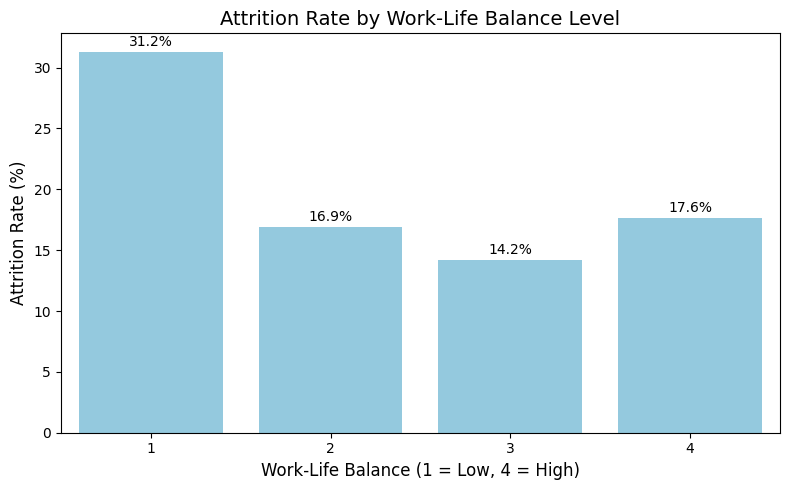

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Attrition rate by Work-Life Balance
attrition_by_wlb = df.groupby('WorkLifeBalance')['AttritionBinary'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=attrition_by_wlb.index, y=attrition_by_wlb.values, color='skyblue')
plt.title('Attrition Rate by Work-Life Balance Level', fontsize=14)
plt.xlabel('Work-Life Balance (1 = Low, 4 = High)', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.xticks([0, 1, 2, 3], ['1', '2', '3', '4'])
for i, v in enumerate(attrition_by_wlb.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

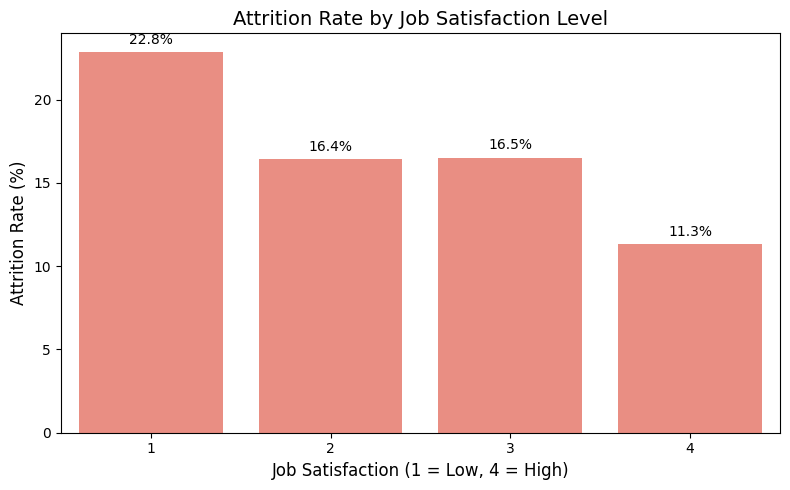

In [ ]:
# Attrition rate by Job Satisfaction
attrition_by_js = df.groupby('JobSatisfaction')['AttritionBinary'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=attrition_by_js.index, y=attrition_by_js.values, color='salmon')
plt.title('Attrition Rate by Job Satisfaction Level', fontsize=14)
plt.xlabel('Job Satisfaction (1 = Low, 4 = High)', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.xticks([0, 1, 2, 3], ['1', '2', '3', '4'])
for i, v in enumerate(attrition_by_js.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

/tmp/ipykernel_999/3770278523.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='WorkLifeBalance', data=df, palette=['green', 'red'])


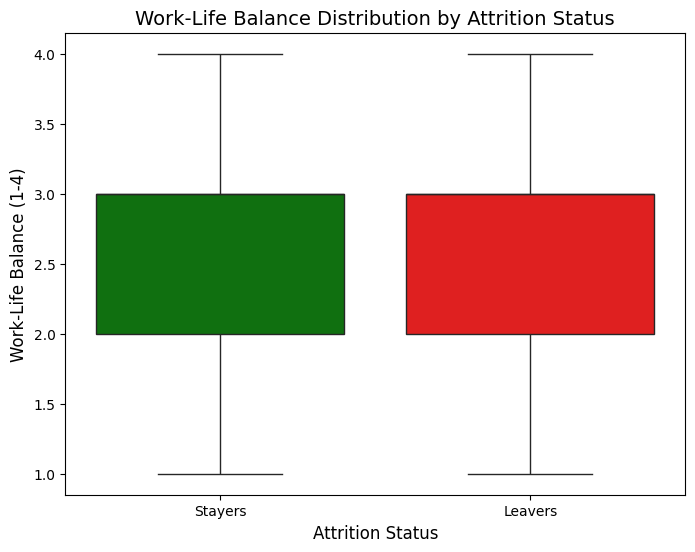

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition', y='WorkLifeBalance', data=df, palette=['green', 'red'])
plt.title('Work-Life Balance Distribution by Attrition Status', fontsize=14)
plt.xlabel('Attrition Status', fontsize=12)
plt.ylabel('Work-Life Balance (1-4)', fontsize=12)
plt.xticks([0, 1], ['Stayers', 'Leavers'])
plt.show()

/tmp/ipykernel_999/3035062196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='JobSatisfaction', data=df, palette=['green', 'red'])


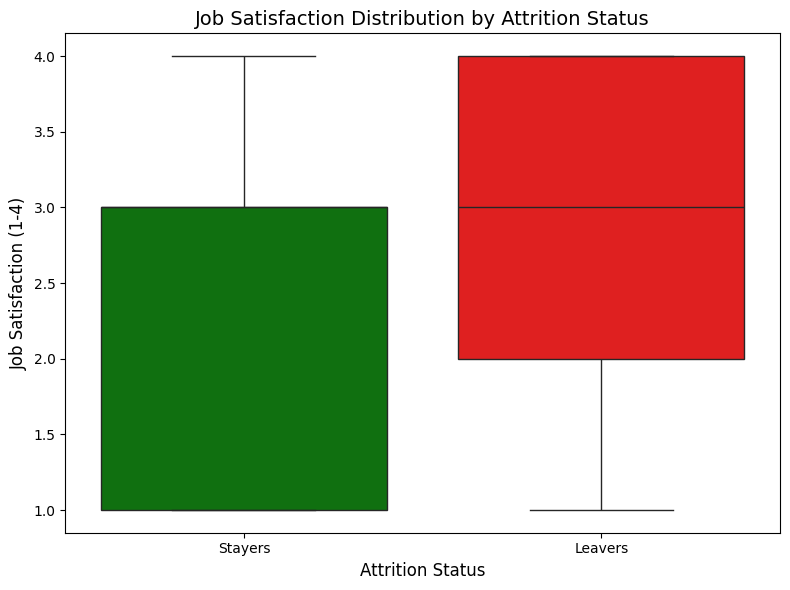

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Attrition', y='JobSatisfaction', data=df, palette=['green', 'red'])
plt.title('Job Satisfaction Distribution by Attrition Status', fontsize=14)
plt.xlabel('Attrition Status', fontsize=12)
plt.ylabel('Job Satisfaction (1-4)', fontsize=12)
plt.xticks([0, 1], ['Stayers', 'Leavers'])
plt.tight_layout()
plt.show()